In [5]:
IS_COLAB_ENV = False

try:
  import google.colab
  IS_COLAB_ENV = True
except:
  pass
IS_COLAB_ENV

False

In [6]:
if IS_COLAB_ENV:
    !pip install tensorflow==2.0.0

In [7]:
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

2025-07-06 19:22:49.211915: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-06 19:22:49.213547: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-06 19:22:49.242912: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-06 19:22:49.243311: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-06 19:22:49.919078: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

In [8]:
IMG_PATH = '../examples/cat.png'
if IS_COLAB_ENV:
  !curl https://imgix.bustle.com/uploads/getty/2024/4/30/f7915a22-0bfe-490f-b41f-25dbb3d2a69b-getty-2141900126.jpg --output cat.jpg
  IMG_PATH = 'cat.jpg'

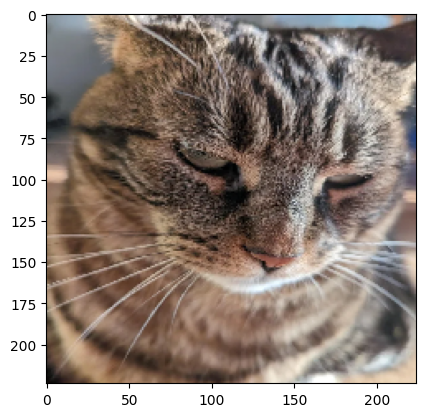

In [9]:
img = image.load_img(IMG_PATH, target_size=(224, 224))
plt.imshow(img)
plt.show()

In [10]:
# check imports and model existence
model = tf.keras.applications.resnet50.ResNet50()

102967424/102967424 [==============================] - 4s 0us/step


In [11]:
import pprint

def predict(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    model = tf.keras.applications.resnet50.ResNet50()
    img_array = image.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)
    img_preprocessed = preprocess_input(img_batch)
    prediction = model.predict(img_preprocessed)
    pprint.pprint(decode_predictions(prediction, top=3)[0])

In [12]:
predict(IMG_PATH)

35363/35363 [==============================] - 0s 1us/step
[('n02123045', 'tabby', 0.675205),
 ('n02123159', 'tiger_cat', 0.21485972),
 ('n02124075', 'Egyptian_cat', 0.09390626)]


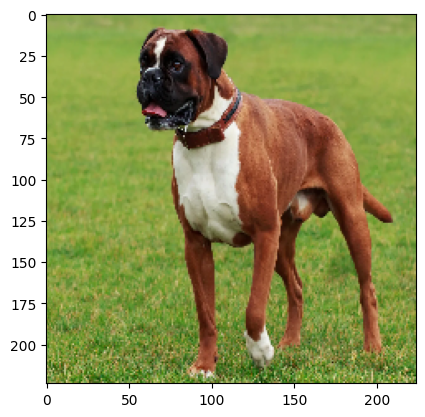

In [13]:
IMG_PATH = '../examples/dog-2.png'
img = image.load_img(IMG_PATH, target_size=(224, 224))
plt.imshow(img)
plt.show()

In [14]:
predict(IMG_PATH)

1/1 [==============================] - 0s 391ms/step
[('n02108089', 'boxer', 0.99258655),
 ('n02108422', 'bull_mastiff', 0.004118068),
 ('n02087394', 'Rhodesian_ridgeback', 0.001517609)]
